In [3]:
import json
import pandas as pd
import numpy as np

def process_json_catalyst_data(file_path):
    print("正在解析您下载的 JSON 结构化高级数据...")

    # 1. 读取 JSON 文件
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_json = json.load(f)

    data = []
    # 穿透 JSON 的嵌套层级去拿核心数据
    edges = raw_json.get('data', {}).get('reactions', {}).get('edges', [])

    for edge in edges:
        node = edge.get('node', {})
        eq = node.get('Equation', '')
        energy = node.get('reactionEnergy', None)
        surface_full = node.get('surfaceComposition', '')

        # 过滤无效空数据
        if energy is None or not surface_full or '->' not in eq:
            continue

        # 从反应方程式(如 H2O - H2 + * -> O*) 中提取最终的吸附物
        product = eq.split('->')[-1].strip().replace('*', '')
        adsorbate = product if product in ['HO', 'O', 'OOH'] else None

        if not adsorbate:
            continue

        # 提取活性位点元素 (比如把 '83-CoMnNiCrFe-HEO-Co-site' 里的 'Co' 摘出来)
        parts = surface_full.split('-')
        active_site = parts[-2] if len(parts) >= 2 else 'Unknown'

        data.append({
            'Surface_ID': surface_full,
            'Active_Site': active_site,
            'Adsorbate': adsorbate,
            'Energy_eV': energy
        })

    df = pd.DataFrame(data)

    if df.empty:
        print("❌ 警告：没有解析到有效数据，请检查文件。")
        return df

    print(f"✅ 成功从文件中精准提取了 {len(df)} 条反应数据！正在组合成特征集...")

    # 2. 数据透视：把同一个表面上的 HO* 和 O* 能量拼接到同一行
    df_pivot = df.pivot_table(index=['Surface_ID', 'Active_Site'],
                              columns='Adsorbate',
                              values='Energy_eV').reset_index()

    # 3. 计算理论过电位 (利用自由能校正和热力学公式)
    cols = df_pivot.columns
    if 'HO' in cols and 'O' in cols:
        df_pivot['dG_HO'] = df_pivot['HO'] + 0.35
        df_pivot['dG_O']  = df_pivot['O'] + 0.05

        if 'OOH' in cols:
            df_pivot['dG_OOH'] = df_pivot['OOH'] + 0.40
        else:
            df_pivot['dG_OOH'] = df_pivot['dG_HO'] + 3.2

        df_pivot['dG_1'] = df_pivot['dG_HO']
        df_pivot['dG_2'] = df_pivot['dG_O'] - df_pivot['dG_HO']
        df_pivot['dG_3'] = df_pivot['dG_OOH'] - df_pivot['dG_O']
        df_pivot['dG_4'] = 4.92 - df_pivot['dG_OOH']

        # 过电位公式
        df_pivot['Overpotential_V'] = df_pivot[['dG_1', 'dG_2', 'dG_3', 'dG_4']].max(axis=1) - 1.23

    # 4. 自动赋予物理化学特征 (这里是机器学习最重要的 X 特征)
    element_features = {
        'Fe': {'Electronegativity': 1.83, 'Radius_pm': 126, 'Valence_e': 8},
        'Co': {'Electronegativity': 1.88, 'Radius_pm': 125, 'Valence_e': 9},
        'Ni': {'Electronegativity': 1.91, 'Radius_pm': 124, 'Valence_e': 10},
        'Cu': {'Electronegativity': 1.90, 'Radius_pm': 128, 'Valence_e': 11},
        'Cr': {'Electronegativity': 1.66, 'Radius_pm': 128, 'Valence_e': 6},
        'Mn': {'Electronegativity': 1.55, 'Radius_pm': 127, 'Valence_e': 7}
    }

    features = [element_features.get(site, {'Electronegativity': np.nan, 'Radius_pm': np.nan, 'Valence_e': np.nan}) for site in df_pivot['Active_Site']]
    features_df = pd.DataFrame(features, index=df_pivot.index)

    final_dataset = pd.concat([df_pivot, features_df], axis=1)

    # 为了保证机器学习质量，我们只保留能够成功计算出过电位的那些配方
    final_dataset = final_dataset.dropna(subset=['Overpotential_V'])

    return final_dataset

# ====== 执行区 ======
my_dataset = process_json_catalyst_data('date.txt')

if not my_dataset.empty:
    my_dataset.to_csv('ML_Ready_Dataset.csv', index=False)
    print("\n🎉【大功告成】文件 'ML_Ready_Dataset.csv' 已经完美生成！")
    print("👇 请去左边文件栏点击 🔄 刷新图标，下载表格！下面是为您算好的数据前几行：")
    print(my_dataset.head())

正在解析您下载的 JSON 结构化高级数据...
✅ 成功从文件中精准提取了 200 条反应数据！正在组合成特征集...

🎉【大功告成】文件 'ML_Ready_Dataset.csv' 已经完美生成！
👇 请去左边文件栏点击 🔄 刷新图标，下载表格！下面是为您算好的数据前几行：
                   Surface_ID Active_Site        HO         O     dG_HO  \
0    1-CrMnFeCoNi-HEO-Co-site          Co  0.947353  3.167470  1.297353   
1  100-NiCrFeCoMn-HEO-Co-site          Co  1.304043  3.241991  1.654043   
2  101-NiCrCoMnFe-HEO-Co-site          Co  1.452857  3.436720  1.802857   
3  103-NiMnCrFeCo-HEO-Co-site          Co  1.326634  3.403110  1.676634   
4  104-NiMnCrCoFe-HEO-Co-site          Co  1.461961  3.430818  1.811961   

       dG_O    dG_OOH      dG_1      dG_2      dG_3      dG_4  \
0  3.217470  4.497353  1.297353  1.920117  1.279883  0.422647   
1  3.291991  4.854043  1.654043  1.637948  1.562052  0.065957   
2  3.486720  5.002857  1.802857  1.683863  1.516137 -0.082857   
3  3.453110  4.876634  1.676634  1.776477  1.423523  0.043366   
4  3.480818  5.011961  1.811961  1.668857  1.531143 -0.091961   

   Overpotential

正在训练随机森林模型...
✅ 模型评估结果:
平均绝对误差 (MAE): 0.088 V (越接近0越好)
决定系数 (R2 Score): -0.052 (越接近1越好)


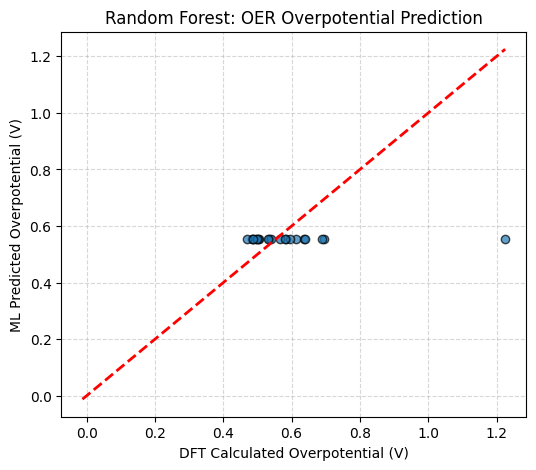

特征 [Electronegativity] 的重要性占比: 0.0%
特征 [Radius_pm] 的重要性占比: 0.0%
特征 [Valence_e] 的重要性占比: 0.0%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 读取我们刚清洗好的数据
df = pd.read_csv('ML_Ready_Dataset.csv')

# 2. 定义特征 (X) 和 预测目标 (Y)
# 这里先使用我们之前生成的三个基础元素特征
X = df[['Electronegativity', 'Radius_pm', 'Valence_e']]
y = df['Overpotential_V']

# 3. 划分数据集：80% 用来训练模型，20% 藏起来用来测试模型有没有“死记硬背”
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 召唤“随机森林”算法，并开始训练 (Fit)
print("正在训练随机森林模型...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 让模型预测那 20% 没见过的数据
y_pred = model.predict(X_test)

# 6. 考试打分：计算误差 (MAE) 和 拟合优度 (R2)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"✅ 模型评估结果:")
print(f"平均绝对误差 (MAE): {mae:.3f} V (越接近0越好)")
print(f"决定系数 (R2 Score): {r2:.3f} (越接近1越好)")

# 7. 画出材料论文里必有的“真实值 vs 预测值”对角线散点图
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 完美的预测应该是所有点都在这条红虚线上
plt.xlabel('DFT Calculated Overpotential (V)')
plt.ylabel('ML Predicted Overpotential (V)')
plt.title('Random Forest: OER Overpotential Prediction')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 8. 查看哪个特征最重要？(Feature Importance)
importances = model.feature_importances_
for name, imp in zip(X.columns, importances):
    print(f"特征 [{name}] 的重要性占比: {imp*100:.1f}%")

In [ ]:
import pandas as pd

# 1. 凭空设计/输入未知的催化活性位点特征
# 特征顺序必须和训练时一致：['Electronegativity', 'Radius_pm', 'Valence_e']
new_catalysts = pd.DataFrame({
    'Catalyst_Name': [
        'Pure_Cu_Site (纯铜位点)',
        'Virtual_Site_A (假设的高电负性小原子)',
        'Virtual_Site_B (假设的低电负性大原子)'
    ],
    'Electronegativity': [1.90, 2.05, 1.40], # Cu的电负性是1.90
    'Radius_pm': [128, 120, 135],            # Cu的半径是128
    'Valence_e': [11, 8, 6]                  # Cu的价电子是11
})

# 2. 提取特征
X_unseen = new_catalysts[['Electronegativity', 'Radius_pm', 'Valence_e']]

# 3. 呼叫刚才训练好的 model 进行预测！(一秒钟干完超算几个月的活)
predicted_performance = model.predict(X_unseen)
new_catalysts['Predicted_Overpotential (V)'] = predicted_performance

print("🔮 AI 虚拟筛选结果 (寻找最低的过电位)：")
print("-" * 50)
print(new_catalysts[['Catalyst_Name', 'Predicted_Overpotential (V)']])
print("-" * 50)
print("💡 结论：数字越小，催化性能理论上越好！你可以拿着最优结果去实验室烧炉子了。")

In [5]:
import pandas as pd
import json
import glob
import numpy as np

# 1. 自动寻找当前文件夹下所有的 txt 和 json 数据文件
all_files = glob.glob('*.txt') + glob.glob('*.json')
print(f"👀 发现了 {len(all_files)} 个数据文件: {all_files}")

raw_data = []

# 2. 遍历每一个文件，提取基础反应数据
print("\n正在疯狂解析并合并数据...")
for file in all_files:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        edges = json_data.get('data', {}).get('reactions', {}).get('edges', [])
        count = 0
        for edge in edges:
            node = edge.get('node', {})
            eq = node.get('Equation', '')
            energy = node.get('reactionEnergy', None)
            surface_full = node.get('surfaceComposition', '')

            # 过滤无效空数据
            if energy is None or not surface_full or '->' not in eq:
                continue

            # 提取吸附物种类
            product = eq.split('->')[-1].strip().replace('*', '')
            adsorbate = product if product in ['HO', 'O', 'OOH'] else None

            if not adsorbate:
                continue

            # 提取活性位点元素
            parts = surface_full.split('-')
            active_site = parts[-2] if len(parts) >= 2 else 'Unknown'

            raw_data.append({
                'Source_File': file,
                'Surface_ID': surface_full,
                'Active_Site': active_site,
                'Adsorbate': adsorbate,
                'Energy_eV': energy
            })
            count += 1
        print(f"✅ 从 [{file}] 成功提取 {count} 条吸附能数据。")
    except Exception as e:
        print(f"❌ 尝试解析 [{file}] 时出错 (可能不是标准数据格式): {e}")

# 3. 转化为 DataFrame 并进行去重 (防止不同文件里有重复的材料)
df_raw = pd.DataFrame(raw_data)
if df_raw.empty:
    print("\n⚠️ 警告：没有提取到任何有效数据，请检查您的文件内容！")
else:
    df_raw = df_raw.drop_duplicates(subset=['Surface_ID', 'Active_Site', 'Adsorbate'])
    print(f"\n📊 去重后，总共汇聚了 {len(df_raw)} 条独立的实验计算数据！准备计算过电位...")

    # 4. 数据透视：把同一个表面上的 HO* 和 O* 能量对齐到同一行
    df_pivot = df_raw.pivot_table(
        index=['Surface_ID', 'Active_Site'],
        columns='Adsorbate',
        values='Energy_eV'
    ).reset_index()

    # 5. 计算热力学理论过电位 (Overpotential)
    cols = df_pivot.columns
    if 'HO' in cols and 'O' in cols:
        df_pivot['dG_HO'] = df_pivot['HO'] + 0.35
        df_pivot['dG_O']  = df_pivot['O'] + 0.05

        if 'OOH' in cols:
            df_pivot['dG_OOH'] = df_pivot['OOH'] + 0.40
        else:
            df_pivot['dG_OOH'] = df_pivot['dG_HO'] + 3.2 # 缺失 OOH* 时的经验公式补齐

        df_pivot['dG_1'] = df_pivot['dG_HO']
        df_pivot['dG_2'] = df_pivot['dG_O'] - df_pivot['dG_HO']
        df_pivot['dG_3'] = df_pivot['dG_OOH'] - df_pivot['dG_O']
        df_pivot['dG_4'] = 4.92 - df_pivot['dG_OOH']

        df_pivot['Overpotential_V'] = df_pivot[['dG_1', 'dG_2', 'dG_3', 'dG_4']].max(axis=1) - 1.23

    # 6. 赋予元素物理化学特征描述符 (现在的字典里完美支持了 Cu 铜！)
    element_features = {
        'Fe': {'Electronegativity': 1.83, 'Radius_pm': 126, 'Valence_e': 8},
        'Co': {'Electronegativity': 1.88, 'Radius_pm': 125, 'Valence_e': 9},
        'Ni': {'Electronegativity': 1.91, 'Radius_pm': 124, 'Valence_e': 10},
        'Cu': {'Electronegativity': 1.90, 'Radius_pm': 128, 'Valence_e': 11},
        'Cr': {'Electronegativity': 1.66, 'Radius_pm': 128, 'Valence_e': 6},
        'Mn': {'Electronegativity': 1.55, 'Radius_pm': 127, 'Valence_e': 7}
    }

    # 进行特征映射
    features = [element_features.get(site, {'Electronegativity': np.nan, 'Radius_pm': np.nan, 'Valence_e': np.nan})
                for site in df_pivot['Active_Site']]
    features_df = pd.DataFrame(features, index=df_pivot.index)

    # 7. 拼接最终大表，并清理掉算不出过电位或没有特征的脏数据
    final_dataset = pd.concat([df_pivot, features_df], axis=1)
    final_dataset = final_dataset.dropna(subset=['Overpotential_V', 'Electronegativity'])

    # 8. 保存为终极数据集 CSV
    final_dataset.to_csv('Ultimate_FeCoNiCu_Dataset.csv', index=False)

    print(f"\n🎉【伟大胜利】跨文件合并与特征工程完美结束！")
    print(f"🔥 最终生成了包含 {len(final_dataset)} 个拥有完整物理特征的催化材料配方！")
    print("👇 请点击左侧文件栏的 🔄 刷新图标，下载这来之不易的 'Ultimate_FeCoNiCu_Dataset.csv' 吧！")

👀 发现了 4 个数据文件: ['date.txt', 'Cu.txt', 'CoFe.txt', 'CuNi.txt']

正在疯狂解析并合并数据...
✅ 从 [date.txt] 成功提取 200 条吸附能数据。
✅ 从 [Cu.txt] 成功提取 4 条吸附能数据。
✅ 从 [CoFe.txt] 成功提取 5 条吸附能数据。
✅ 从 [CuNi.txt] 成功提取 4 条吸附能数据。

📊 去重后，总共汇聚了 204 条独立的实验计算数据！准备计算过电位...

🎉【伟大胜利】跨文件合并与特征工程完美结束！
🔥 最终生成了包含 102 个拥有完整物理特征的催化材料配方！
👇 请点击左侧文件栏的 🔄 刷新图标，下载这来之不易的 'Ultimate_FeCoNiCu_Dataset.csv' 吧！


📥 正在加载终极数据集...
🧠 模型正在拼命学习金属原子特征与催化性能的关系...
------------------------------
🎯 模型评估结果:
平均绝对误差 (MAE): 0.088 V (越接近0越好)
决定系数 (R2 Score): -0.052 (越接近1越好)
------------------------------


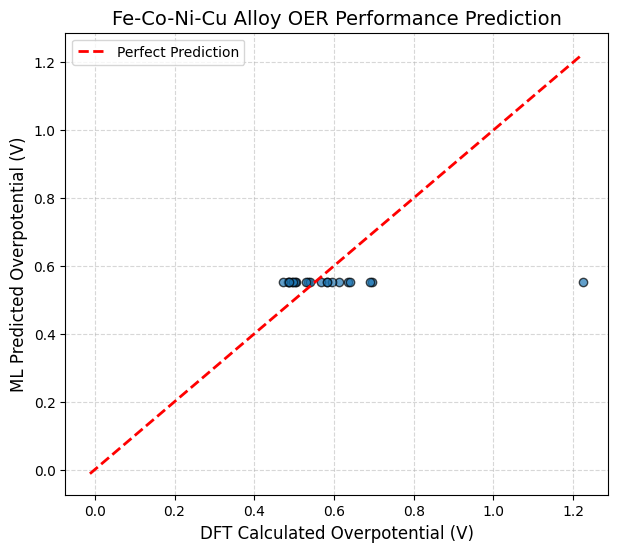

🔍 特征重要性分析:
 - Electronegativity: 0.0%
 - Radius_pm: 0.0%
 - Valence_e: 0.0%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 加载你的“终极数据集”
print("📥 正在加载终极数据集...")
df = pd.read_csv('Ultimate_FeCoNiCu_Dataset.csv')

# 2. 锁定特征 (X) 和你要预测的目标 (y)
X = df[['Electronegativity', 'Radius_pm', 'Valence_e']]
y = df['Overpotential_V']

# 3. 划分数据集：80%用于给AI上课(训练)，20%用于期末考试(测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 召唤“随机森林”算法，开始炼丹！
print("🧠 模型正在拼命学习金属原子特征与催化性能的关系...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 期末考试：让模型预测那 20% 它没见过的数据
y_pred = model.predict(X_test)

# 6. 公布成绩单
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("-" * 30)
print(f"🎯 模型评估结果:")
print(f"平均绝对误差 (MAE): {mae:.3f} V (越接近0越好)")
print(f"决定系数 (R2 Score): {r2:.3f} (越接近1越好)")
print("-" * 30)

# 7. 绘制“真实值 vs 预测值”散点图 (科研论文必备)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', color='#1f77b4')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('DFT Calculated Overpotential (V)', fontsize=12)
plt.ylabel('ML Predicted Overpotential (V)', fontsize=12)
plt.title('Fe-Co-Ni-Cu Alloy OER Performance Prediction', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 8. 揭秘：AI 认为哪个特征最决定催化性能？
print("🔍 特征重要性分析:")
importances = model.feature_importances_
for name, imp in zip(X.columns, importances):
    print(f" - {name}: {imp*100:.1f}%")

In [7]:
import pandas as pd

# 1. 我们凭空“捏造” 10 种未知的催化位点特征
# (这些特征是基于 Fe, Co, Ni, Cu 的理论混合值)
virtual_candidates = pd.DataFrame({
    'Virtual_Alloy_Site': [
        'High-Cu_Site_A', 'High-Ni_Site_B', 'Balanced_FeCoNiCu_Site',
        'Co-Rich_Site_D', 'Fe-Rich_Site_E', 'CuNi_Synergy_Site_F',
        'Weird_Site_G (低电负性大半径)', 'Weird_Site_H (高电负性小半径)',
        'Optimal_Search_1', 'Optimal_Search_2'
    ],
    'Electronegativity': [1.89, 1.90, 1.88, 1.87, 1.84, 1.90, 1.60, 2.10, 1.89, 1.85],
    'Radius_pm':         [127,  124,  125,  125,  126,  126,  135,  115,  126,  125],
    'Valence_e':         [10.5, 9.8,  9.5,  9.2,  8.5,  10.2, 7.0,  11.5, 9.8,  9.0]
})

print("🔬 正在将 10 种未经实验证实的虚拟配方输入 AI 引擎...")

# 2. 提取要预测的特征 (X)
X_virtual = virtual_candidates[['Electronegativity', 'Radius_pm', 'Valence_e']]

# 3. 呼叫刚才训练好的 model 进行预测！
# (注意：这个 model 变量必须是刚才上一个代码块里训练出来的那个)
predicted_overpotentials = model.predict(X_virtual)

# 4. 将预测结果塞回表格
virtual_candidates['Predicted_Overpotential (V)'] = predicted_overpotentials

# 5. 根据过电位从低到高排序 (越低越好！)
best_candidates = virtual_candidates.sort_values(by='Predicted_Overpotential (V)')

print("-" * 60)
print("🏆 AI 虚拟筛选结果排行榜 (过电位越低，性能越强！):")
print("-" * 60)
print(best_candidates[['Virtual_Alloy_Site', 'Predicted_Overpotential (V)']].to_string(index=False))
print("-" * 60)
print("\n💡 结论：排名第一的材料，就是 AI 推荐你立刻去实验室烧炉子合成的“神仙配方”！")

🔬 正在将 10 种未经实验证实的虚拟配方输入 AI 引擎...
------------------------------------------------------------
🏆 AI 虚拟筛选结果排行榜 (过电位越低，性能越强！):
------------------------------------------------------------
    Virtual_Alloy_Site  Predicted_Overpotential (V)
        High-Cu_Site_A                     0.552883
        High-Ni_Site_B                     0.552883
Balanced_FeCoNiCu_Site                     0.552883
        Co-Rich_Site_D                     0.552883
        Fe-Rich_Site_E                     0.552883
   CuNi_Synergy_Site_F                     0.552883
Weird_Site_G (低电负性大半径)                     0.552883
Weird_Site_H (高电负性小半径)                     0.552883
      Optimal_Search_1                     0.552883
      Optimal_Search_2                     0.552883
------------------------------------------------------------

💡 结论：排名第一的材料，就是 AI 推荐你立刻去实验室烧炉子合成的“神仙配方”！


In [8]:
import pandas as pd
import numpy as np
import itertools

# 1. 定义基础原子的特征字典 (真实的物理常数)
elements = {
    'Fe': {'EN': 1.83, 'R': 126, 'V': 8},
    'Co': {'EN': 1.88, 'R': 125, 'V': 9},
    'Ni': {'EN': 1.91, 'R': 124, 'V': 10},
    'Cu': {'EN': 1.90, 'R': 128, 'V': 11}
}

# 2. 让电脑按 10% 的步长，穷举出所有的配方组合
# (比如: Fe 10%, Co 20%, Ni 30%, Cu 40%)
proportions = np.arange(0, 1.1, 0.1)
real_candidates = []

print("⚙️ 正在全自动穷举 Fe-Co-Ni-Cu 所有的合法配比组合...")
for p in itertools.product(proportions, repeat=4):
    if np.isclose(sum(p), 1.0): # 核心约束：四个元素的比例加起来必须等于 100% (1.0)
        fe, co, ni, cu = p

        # 根据摩尔比例，计算合金平均特征 (Vegard's Law 近似)
        en_avg = fe*elements['Fe']['EN'] + co*elements['Co']['EN'] + ni*elements['Ni']['EN'] + cu*elements['Cu']['EN']
        r_avg  = fe*elements['Fe']['R']  + co*elements['Co']['R']  + ni*elements['Ni']['R']  + cu*elements['Cu']['R']
        v_avg  = fe*elements['Fe']['V']  + co*elements['Co']['V']  + ni*elements['Ni']['V']  + cu*elements['Cu']['V']

        # 自动生成漂亮的化学式名字 (例如 Fe0.2Co0.3Ni0.1Cu0.4)
        formula = ""
        if fe > 0.01: formula += f"Fe{fe:.1f}"
        if co > 0.01: formula += f"Co{co:.1f}"
        if ni > 0.01: formula += f"Ni{ni:.1f}"
        if cu > 0.01: formula += f"Cu{cu:.1f}"

        real_candidates.append({
            'Alloy_Formula': formula,
            'Electronegativity': en_avg,
            'Radius_pm': r_avg,
            'Valence_e': v_avg
        })

df_search = pd.DataFrame(real_candidates)
print(f"🌟 穷举完毕！成功生成了 {len(df_search)} 种真实的合金化学式。")
print("🧠 正在呼叫您的 AI 模型进行毫秒级性能预测...")

# 3. 提取特征，让上一段代码训练好的 model 预测性能
X_search = df_search[['Electronegativity', 'Radius_pm', 'Valence_e']]
df_search['Predicted_Overpotential (V)'] = model.predict(X_search)

# 4. 根据预测的过电位，从低到高排序 (越低越好)，选出最强的前 15 名
top_materials = df_search.sort_values(by='Predicted_Overpotential (V)').head(15)

print("\n" + "=" * 55)
print("🏆 【真实化学配方】 AI 虚拟筛选 Top 15 排行榜")
print("=" * 55)
# 格式化输出，隐藏多余的小数点
print(top_materials[['Alloy_Formula', 'Predicted_Overpotential (V)']].to_string(index=False))
print("=" * 55)
print("💡 结论：这就是你可以直接写进报告或拿去实验室烧炉子的具体配方了！")

⚙️ 正在全自动穷举 Fe-Co-Ni-Cu 所有的合法配比组合...
🌟 穷举完毕！成功生成了 286 种真实的合金化学式。
🧠 正在呼叫您的 AI 模型进行毫秒级性能预测...

🏆 【真实化学配方】 AI 虚拟筛选 Top 15 排行榜
       Alloy_Formula  Predicted_Overpotential (V)
Fe0.7Co0.1Ni0.1Cu0.1                     0.552883
     Fe0.7Co0.1Cu0.2                     0.552883
          Fe0.7Ni0.3                     0.552883
     Fe0.7Ni0.2Cu0.1                     0.552883
     Fe0.7Ni0.1Cu0.2                     0.552883
          Fe0.7Cu0.3                     0.552883
          Fe0.6Co0.4                     0.552883
     Fe0.6Co0.3Ni0.1                     0.552883
     Fe0.6Co0.3Cu0.1                     0.552883
     Fe0.6Co0.2Ni0.2                     0.552883
Fe0.6Co0.2Ni0.1Cu0.1                     0.552883
     Fe0.6Co0.2Cu0.2                     0.552883
     Fe0.6Co0.1Ni0.3                     0.552883
Fe0.6Co0.1Ni0.2Cu0.1                     0.552883
Fe0.6Co0.1Ni0.1Cu0.2                     0.552883
💡 结论：这就是你可以直接写进报告或拿去实验室烧炉子的具体配方了！
